# COVID-19 — Classification Dataset Réel
## Même structure que le notebook 02 — comparaison directe possible

Entraînement binaire (COVID+ vs COVID−) avec Random Forest, Logistic Regression et XGBoost.
Grid Search + class_weight balanced pour gérer le déséquilibre 80/20.

In [1]:
import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('OK')

OK


## 1. Chargement et preprocessing

In [2]:
df = pd.read_csv('Covid Dataset.csv')

# Encodage Yes/No → 1/0
df_enc = df.copy()
for col in df.columns:
    df_enc[col] = (df[col].str.strip() == 'Yes').astype(int)

# Supprimer colonnes constantes
constant_cols = [c for c in df_enc.columns if df_enc[c].std() == 0]
df_enc = df_enc.drop(columns=constant_cols)
print(f'Colonnes constantes supprimées : {constant_cols}')

FEATURES = [c for c in df_enc.columns if c != 'COVID-19']
X = df_enc[FEATURES]
y = df_enc['COVID-19']

print(f'Shape : {X.shape}')
print(f'COVID+ : {y.sum()} ({y.mean()*100:.1f}%) | COVID- : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')

Colonnes constantes supprimées : ['Wearing Masks', 'Sanitization from Market']
Shape : (5434, 18)
COVID+ : 4383 (80.7%) | COVID- : 1051 (19.3%)


## 2. Train-Test Split (stratifié)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Train COVID+ : {y_train.mean()*100:.1f}% | Test COVID+ : {y_test.mean()*100:.1f}%')

Train : (4347, 18) | Test : (1087, 18)
Train COVID+ : 80.7% | Test COVID+ : 80.7%


## 3. Entraînement — Grid Search + class_weight balanced

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

count_neg = (y_train == 0).sum()
count_pos = (y_train == 1).sum()
ratio = count_neg / count_pos
print(f'scale_pos_weight XGBoost : {ratio:.4f}')

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest':       RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost':            XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss', scale_pos_weight=ratio)
}

grids = {
    'LogisticRegression': {'C': [0.1, 1.0, 10.0]},
    'RandomForest':       {'n_estimators': [50, 100], 'max_depth': [5, 10, None]},
    'XGBoost':            {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
}

trained = {}
results = []
predictions = {}

for name, model in base_models.items():
    print(f'-> Optimisation {name}...')
    gs = GridSearchCV(model, grids[name], scoring='f1', cv=3, n_jobs=1)
    gs.fit(X_train, y_train)
    trained[name] = gs.best_estimator_
    y_pred = gs.best_estimator_.predict(X_test)
    predictions[name] = y_pred
    f1  = f1_score(y_test, y_pred, average='binary')
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'F1': f1, 'Accuracy': acc, 'Best_Params': str(gs.best_params_)})
    print(f'   F1 Test : {f1:.4f} | Accuracy : {acc:.4f}')

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print('\n', results_df[['Model','F1','Accuracy']].to_string(index=False))

scale_pos_weight XGBoost : 0.2399
-> Optimisation LogisticRegression...
   F1 Test : 0.9704 | Accuracy : 0.9531
-> Optimisation RandomForest...
   F1 Test : 0.9879 | Accuracy : 0.9807
-> Optimisation XGBoost...
   F1 Test : 0.9855 | Accuracy : 0.9770

              Model       F1  Accuracy
      RandomForest 0.987882  0.980681
           XGBoost 0.985541  0.977001
LogisticRegression 0.970366  0.953082


## 4. Rapports de classification détaillés

In [5]:
for name, y_pred in predictions.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['COVID-', 'COVID+']))


=== LogisticRegression ===
              precision    recall  f1-score   support

      COVID-       0.83      0.96      0.89       210
      COVID+       0.99      0.95      0.97       877

    accuracy                           0.95      1087
   macro avg       0.91      0.95      0.93      1087
weighted avg       0.96      0.95      0.95      1087


=== RandomForest ===
              precision    recall  f1-score   support

      COVID-       0.91      1.00      0.95       210
      COVID+       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087


=== XGBoost ===
              precision    recall  f1-score   support

      COVID-       0.89      1.00      0.94       210
      COVID+       1.00      0.97      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.96      1087
weighte

## 5. Matrices de confusion

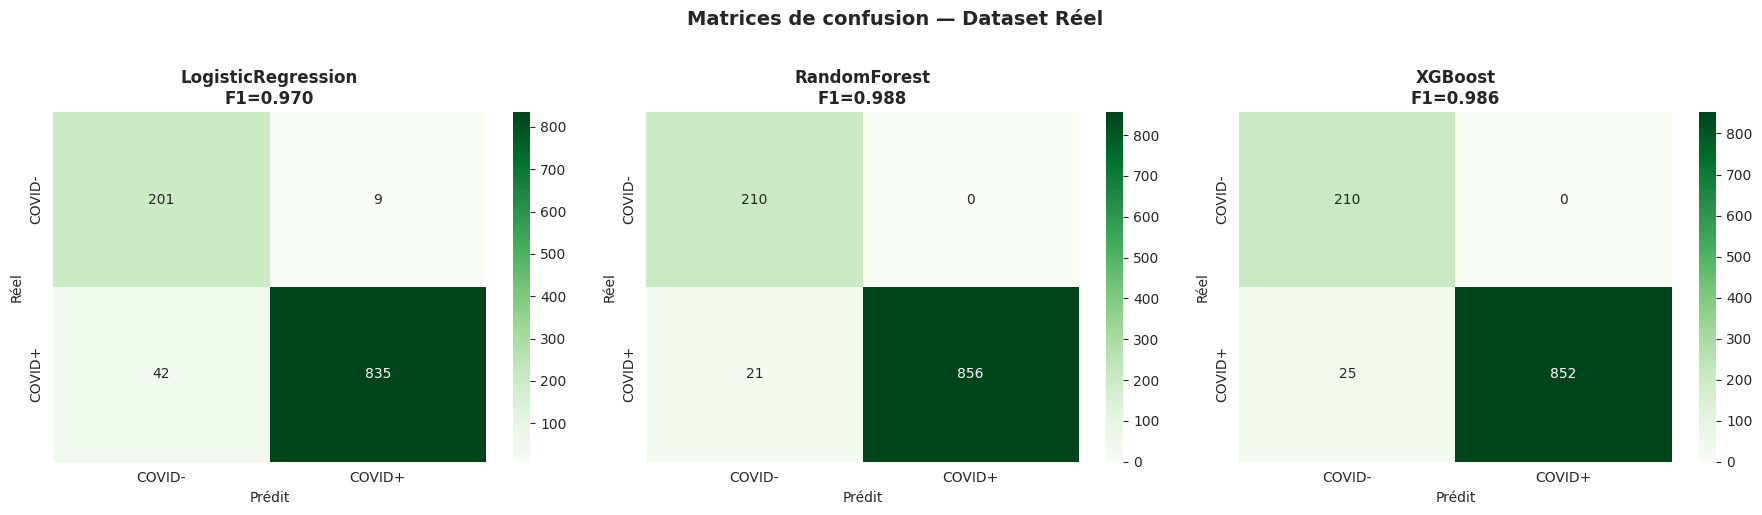

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=['COVID-', 'COVID+'], yticklabels=['COVID-', 'COVID+'])
    f1 = f1_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nF1={f1:.3f}', fontweight='bold')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Réel')
plt.suptitle('Matrices de confusion — Dataset Réel', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('04_cm_reel.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Comparaison F1-Score

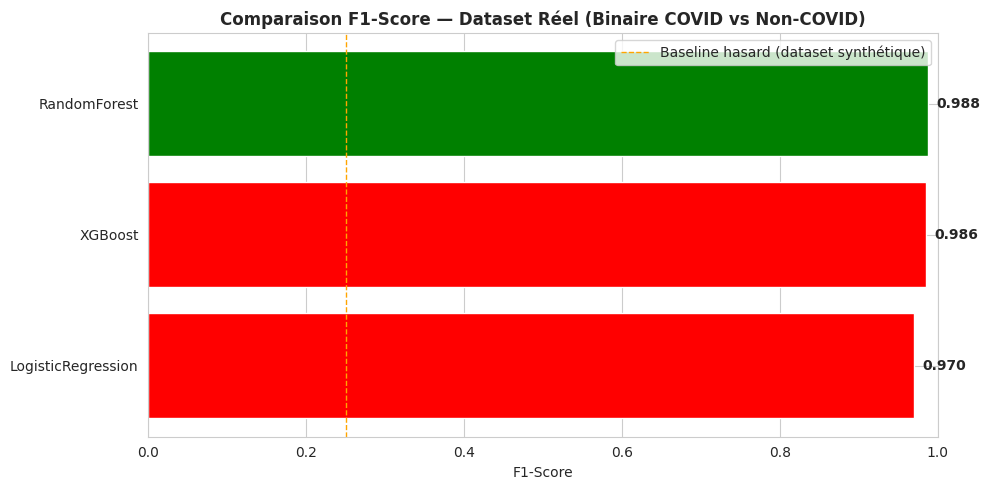

In [7]:
sorted_df = results_df.sort_values('F1', ascending=True)
colors = ['green' if v == sorted_df['F1'].max() else 'red' for v in sorted_df['F1']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_df['Model'], sorted_df['F1'], color=colors)
ax.set_xlabel('F1-Score')
ax.set_title('Comparaison F1-Score — Dataset Réel (Binaire COVID vs Non-COVID)',
             fontweight='bold')
ax.set_xlim([0, 1])
ax.axvline(0.25, color='orange', linestyle='--', linewidth=1, label='Baseline hasard (dataset synthétique)')
ax.legend()
for bar, val in zip(bars, sorted_df['F1']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('04_f1_reel.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Importance des features (Random Forest)

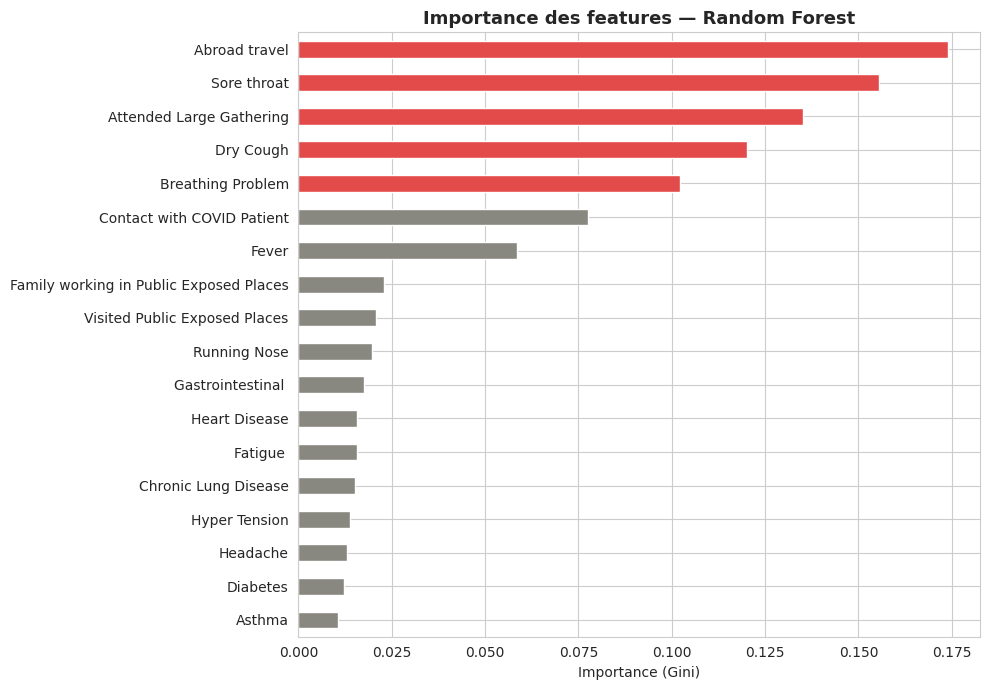

In [8]:
rf = trained['RandomForest']
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#E24B4A' if v >= importances.quantile(0.75) else '#888780' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors_imp)
ax.set_title('Importance des features — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Vérification de cohérence — test sur profils types

In [9]:
rf = trained['RandomForest']

# Patient A : aucun symptôme
patient_a = {col: 0 for col in FEATURES}

# Patient B : symptômes forts + contact + voyage
patient_b = {col: 0 for col in FEATURES}
patient_b['Breathing Problem'] = 1
patient_b['Fever'] = 1
patient_b['Dry Cough'] = 1
patient_b['Sore throat'] = 1
patient_b['Contact with COVID Patient'] = 1
patient_b['Abroad travel'] = 1

# Patient C : symptômes légers
patient_c = {col: 0 for col in FEATURES}
patient_c['Headache'] = 1
patient_c['Fatigue '] = 1

for label, patient in [('A (aucun symptôme)', patient_a),
                        ('B (symptômes sévères + contact)', patient_b),
                        ('C (symptômes légers)', patient_c)]:
    X_p = pd.DataFrame([patient])[FEATURES]
    proba = rf.predict_proba(X_p)[0][1]
    print(f'Patient {label} → COVID proba : {proba*100:.1f}%')

Patient A (aucun symptôme) → COVID proba : 2.3%
Patient B (symptômes sévères + contact) → COVID proba : 100.0%
Patient C (symptômes légers) → COVID proba : 0.1%


## 9. Sauvegarde du modèle Random Forest pour Streamlit

In [10]:
# Modèle Random Forest pour le chatbot
rf_final = trained['RandomForest']
joblib.dump(rf_final, 'best_covid_randomforest_reel.pkl')
print('-> [OK] best_covid_randomforest_reel.pkl')

# Données pour notebooks suivants
data_dict = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'FEATURES': FEATURES,
    'trained_models': trained,
    'results_df': results_df
}
with open('classification_reel_data.pkl', 'wb') as f:
    pickle.dump(data_dict, f)
print('-> [OK] classification_reel_data.pkl')

print('\n==================================================')
print('✨ CLASSIFICATION DATASET RÉEL — TERMINÉ')
print('==================================================')
best = results_df.iloc[0]
print(f'Meilleur modèle : {best["Model"]} (F1 = {best["F1"]:.4f})')

-> [OK] best_covid_randomforest_reel.pkl
-> [OK] classification_reel_data.pkl

✨ CLASSIFICATION DATASET RÉEL — TERMINÉ
Meilleur modèle : RandomForest (F1 = 0.9879)
